<a href="https://colab.research.google.com/github/mikiube/Fase-1/blob/main/desafio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 - importar as libs importantes para visualização e manipulação dos dados.

In [1]:
#Libs

import pandas as pd
import numpy as np

#libs gráficas
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#Avisos
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Durante a comparação com as aulas estavamos utilizando o formato .XLS para o arquivo base ,após erros de leituras,fiz as verificação se não havia nenhum letra incorreta e observei que
#que o arquivo do tech challenge é formato .CSV,logo tive que pesquisar qual seria o comando correto.

nps = pd.read_csv('desafio_nps_fase_1.csv')
nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Irei verificar se a base de dados está concisa para uma analise dados completa

In [3]:
nps.shape

(2500, 19)

Verificar tipos de dados

In [4]:
nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


Verificar se existem valores nulos

In [5]:
nps.isnull().sum().sum()

np.int64(0)

verificando colunas da tabela

In [6]:
nps.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

verificando duplicatas de dados

In [7]:
nps.duplicated().sum()

np.int64(0)

Verificando a estrutura

In [13]:
nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Criando uma dataframe limpo para analise

In [16]:
df_nps = nps[['customer_age','customer_region','customer_tenure_months','order_value','items_quantity','discount_value','payment_installments','delivery_time_days','delivery_delay_days','freight_value','delivery_attempts','customer_service_contacts','resolution_time_days','nps_score','repeat_purchase_30d','complaints_count','csat_internal_score',]]

Traduzindo as colunas

In [18]:
df_nps.columns = ['idade_cliente','regiao_cliente','meses_contrato','valor_pedido','quantidade_itens','valor_desconto','pagamento_parcelado','tempo_entrega_dias','tempo_atraso_dias','valor_frete','tentativas_entrega','contatos_relacionamento','tempo_resolucao_dias','pontuacao_nps','recompra_30d','contagem_reclamacoes','pontuacao_csat_interno']

Estatistica descritiva da tabela

In [19]:
#Como boa pratica apenas 2 casas decimais para visualização.
df_nps.describe().round(2)

,idade_cliente,meses_contrato,valor_pedido,quantidade_itens,valor_desconto,pagamento_parcelado,tempo_entrega_dias,tempo_atraso_dias,valor_frete,tentativas_entrega,contatos_relacionamento,tempo_resolucao_dias,pontuacao_nps,recompra_30d,contagem_reclamacoes,pontuacao_csat_interno
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


De acordo com pesquisa, dado a nota NPS pelo usuário a nota é categorizado da seguinte forma.

0 até 6 detratores
7 e 8 neutros
9 e 10 promotores

In [24]:
def nps_class(df):
    if df['pontuacao_nps']>=9:
        return 'Promotor'
    elif df['pontuacao_nps']<=6:
        return 'Detrator'
    else:
        return 'Neutro'


In [30]:
df_nps['classe'] = df_nps.apply(nps_class, axis=1)
df_nps['classe']

,classe
0,Neutro
1,Detrator
2,Detrator
3,Detrator
4,Neutro
...,...
2495,Detrator
2496,Detrator
2497,Neutro
2498,Detrator


Contagem da categorização.


In [34]:
df_nps['classe'].value_counts()

,count
classe,
Detrator,1851
Neutro,539
Promotor,110


Por região do consumidor

In [103]:
#Fitro regiao
df_nps_regiao = pd.DataFrame(df_nps.groupby('regiao_cliente')[['pontuacao_nps','pontuacao_csat_interno']].mean().round(2)).reset_index()

In [99]:
#identificamos que é um problema global.
df_nps_regiao

,regiao_cliente,pontuacao_nps,pontuacao_csat_interno
0,Centro-Oeste,4.21,3.02
1,Nordeste,4.42,3.02
2,Norte,4.38,2.94
3,Sudeste,4.37,2.93
4,Sul,4.49,2.81


Por idade do consumidor

In [38]:
#Fitro idade
df_nps_idade = pd.DataFrame(df_nps.groupby('idade_cliente')[['pontuacao_nps']].mean().round(2)).reset_index()

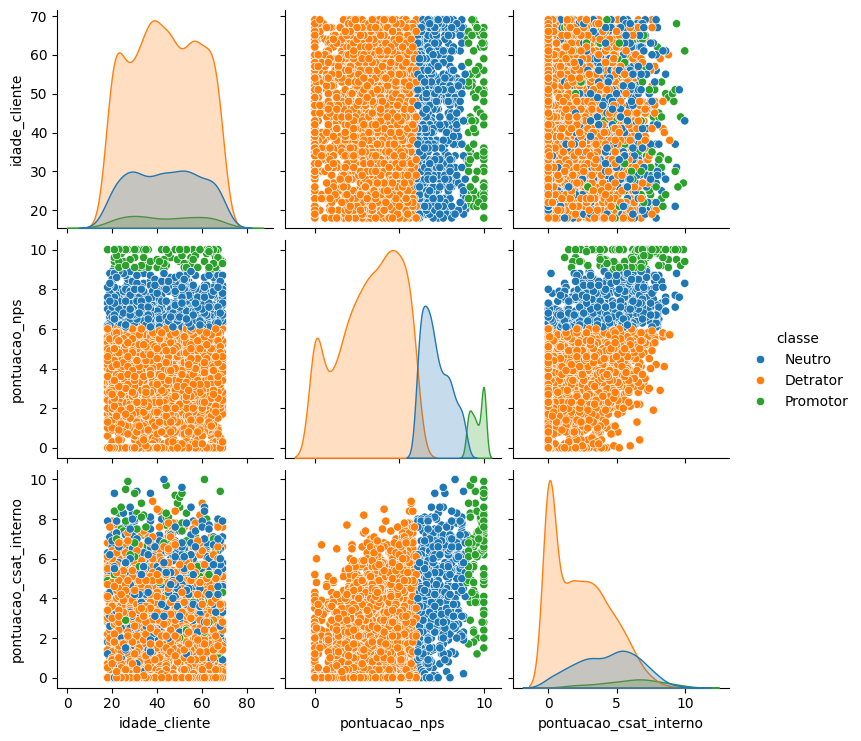

In [59]:
sns.pairplot(df_nps, vars=['idade_cliente','pontuacao_nps','pontuacao_csat_interno'], hue = 'classe')

verificando correlação geral

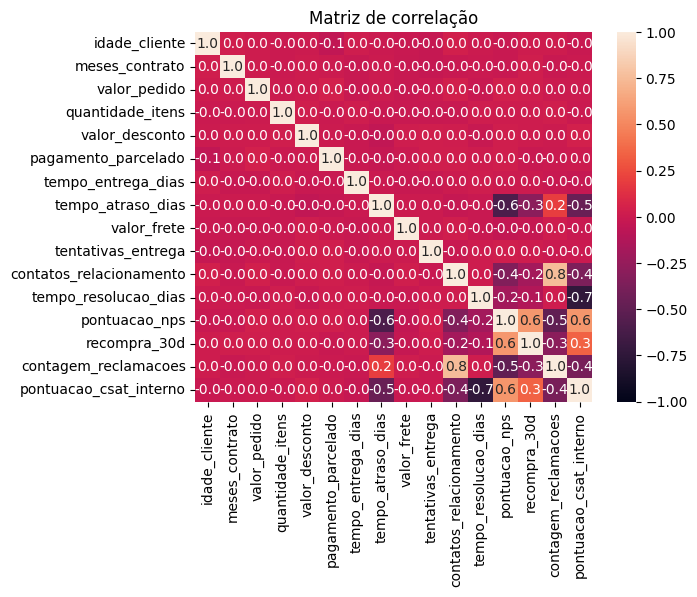

In [104]:
#percebemos através da correlação que a pontuação NPS está ligado a atraso logistico e reclamações e contatos com o relacionamento.
cols_corr = [c for c in ['idade_cliente','meses_contrato','valor_pedido','quantidade_itens','valor_desconto','pagamento_parcelado','tempo_entrega_dias','tempo_atraso_dias','valor_frete','tentativas_entrega','contatos_relacionamento','tempo_resolucao_dias','pontuacao_nps','recompra_30d','contagem_reclamacoes','pontuacao_csat_interno'] if c in df_nps.columns]
corr = df_nps[cols_corr].corr()

sns.heatmap(corr, annot=True, fmt=".1f", cmap="rocket", vmin=-1, vmax=1)
plt.title("Matriz de correlação")

plt.show()

IDADE X TEMPO DE ENTREGA

<Axes: xlabel='idade_cliente', ylabel='tempo_entrega_dias'>

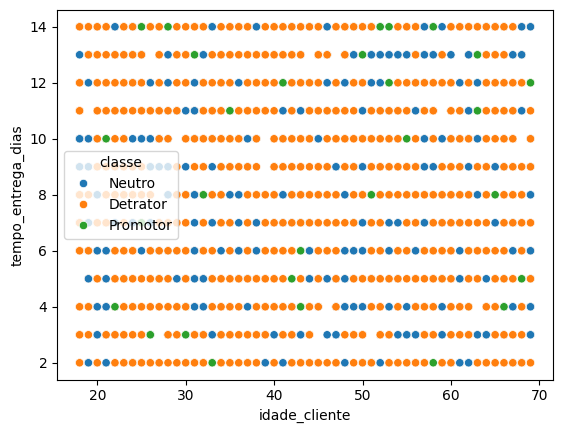

In [65]:
#a linha de reciocionio para esse modelo foi que jovens estão menos intolerantes a longas jornadas,porem atraves deste grafico vemos que está bem disperso,logo não há impacto no NPS.
sns.scatterplot(data=df_nps, x='idade_cliente', y='tempo_entrega_dias', hue = 'classe')

ATRASO x NPS

<Axes: xlabel='tempo_atraso_dias', ylabel='pontuacao_nps'>

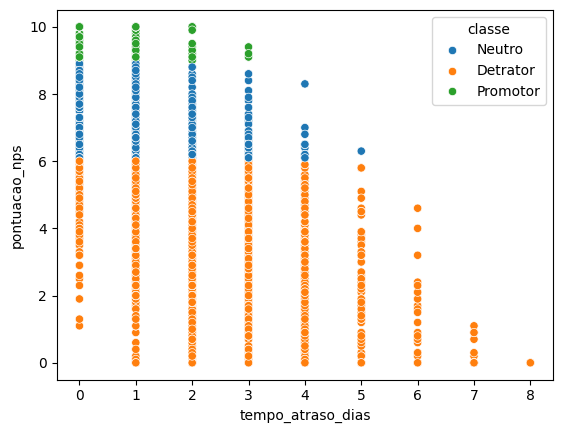

In [83]:
#identificamos que não possuimos mais promotores apos o terceiro dia de atraso,e perdemos os neutros apos 5 dias de atraso.
sns.scatterplot(data=df_nps, x='tempo_atraso_dias', y='pontuacao_nps', hue = 'classe')

CSAT X NPS

<Axes: xlabel='pontuacao_csat_interno', ylabel='pontuacao_nps'>

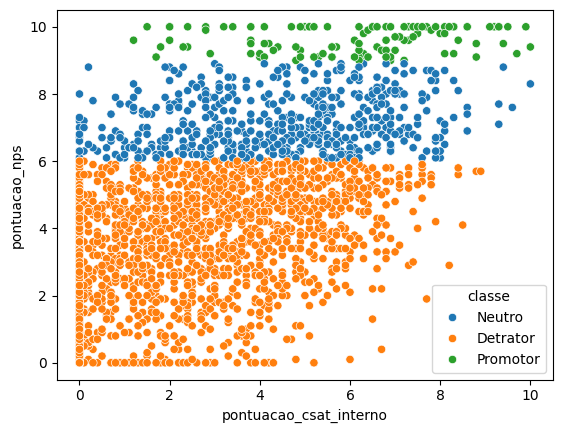

In [97]:
sns.scatterplot(data=df_nps, x='pontuacao_csat_interno', y='pontuacao_nps', hue = 'classe')

CONTATO RELACIONAMENTO X TEMPO DE RESOLUÇÂO

<Axes: xlabel='tempo_resolucao_dias', ylabel='contatos_relacionamento'>

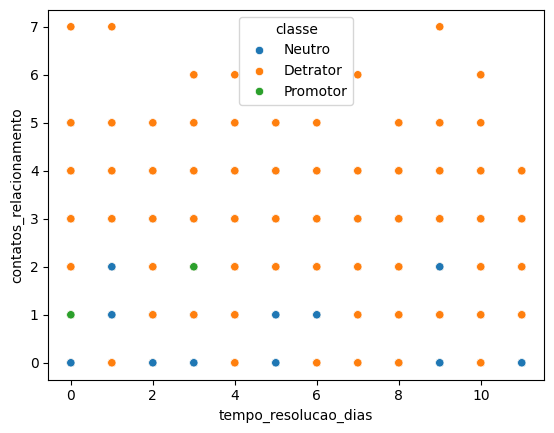

In [102]:
sns.scatterplot(data=df_nps, x='tempo_resolucao_dias', y='contatos_relacionamento', hue = 'classe')

ATRASO x REGIAO X NPS

In [109]:
df_nps_metrics_by_region = df_nps.groupby('regiao_cliente')[['pontuacao_nps', 'tempo_atraso_dias']].mean().round(2)
df_nps_metrics_by_region

,pontuacao_nps,tempo_atraso_dias
regiao_cliente,,
Centro-Oeste,4.21,2.22
Nordeste,4.42,2.19
Norte,4.38,2.14
Sudeste,4.37,2.22
Sul,4.49,2.17


NPS X LONGEVIDADE

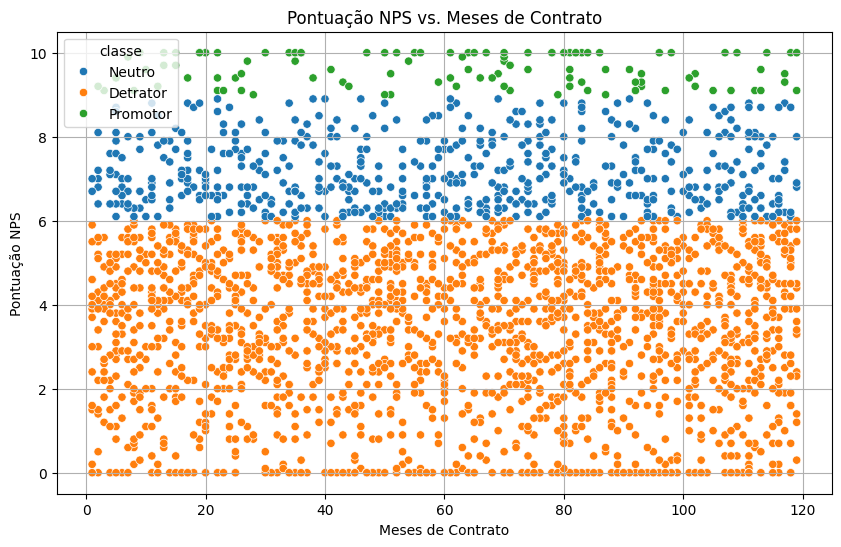

In [112]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_nps, x='meses_contrato', y='pontuacao_nps', hue='classe')
plt.title('Pontuação NPS vs. Meses de Contrato')
plt.xlabel('Meses de Contrato')
plt.ylabel('Pontuação NPS')
plt.grid(True)
plt.show()